# Logistic Regression
**Logistic Regression is built from Linear Regression.**

---

# Step 1: We start exactly like Linear Regression

First, we calculate a linear equation:

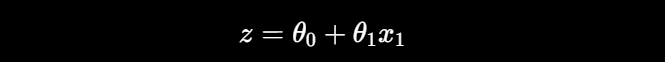



This part is **identical to linear regression.**

Example:

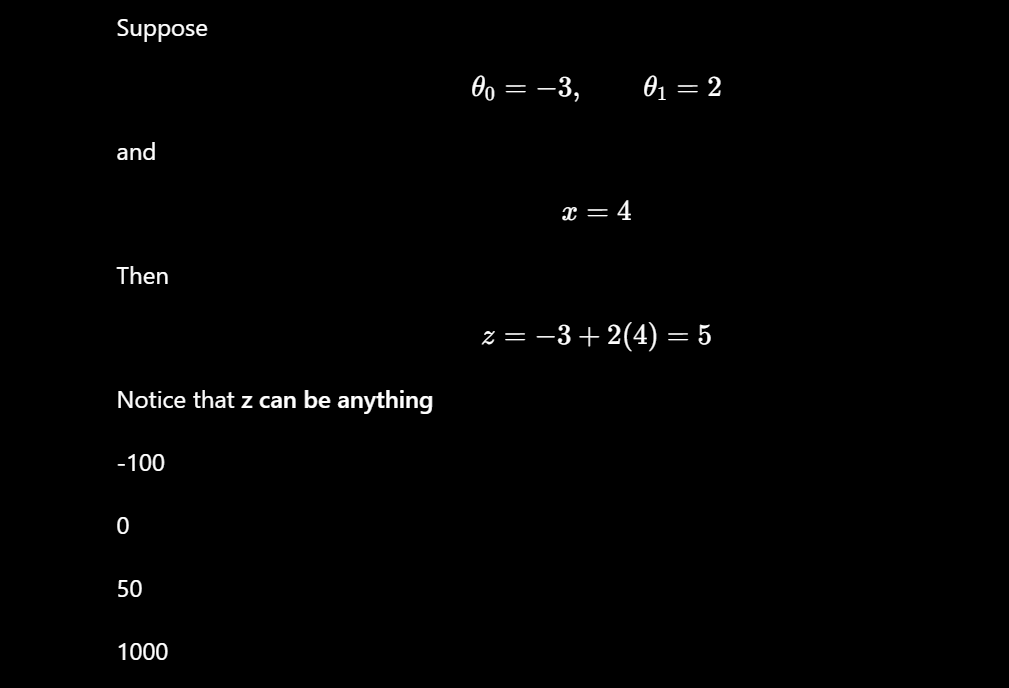

But we need probabilities

---

# Step 2: But classification needs probabilities

Suppose we want to predict

Spam or Not Spam

Disease or Healthy

Pass or Fail

We cannot say

"The answer is 7.3"

That makes no sense.

Instead we need something like

Probability = 0.91

or

Probability = 0.12

So we need to convert

[
z
]

into

a number between **0 and 1**.

---

# Step 3: Sigmoid function does that

So instead of using

[
z
]

directly,

we pass it into the sigmoid function.

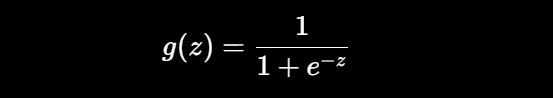


Think of sigmoid as a converter.

```
Linear equation
      ↓
z = 5
      ↓
Sigmoid
      ↓
0.993
```

or

```
Linear equation
      ↓
z = -4
      ↓
Sigmoid
      ↓
0.018
```

---

# Step 4: Why sigmoid?

Because no matter what z is,

Sigmoid always produces

[
0<g(z)<1
]

Examples

| z   | Sigmoid  |
| --- | -------- |
| -10 | 0.000045 |
| -5  | 0.0067   |
| -2  | 0.119    |
| 0   | 0.5      |
| 2   | 0.881    |
| 5   | 0.993    |
| 10  | 0.99995  |

So huge negative numbers become close to 0.

Huge positive numbers become close to 1.

---

# Step 5: The graph

The S-shaped curve is the sigmoid function.
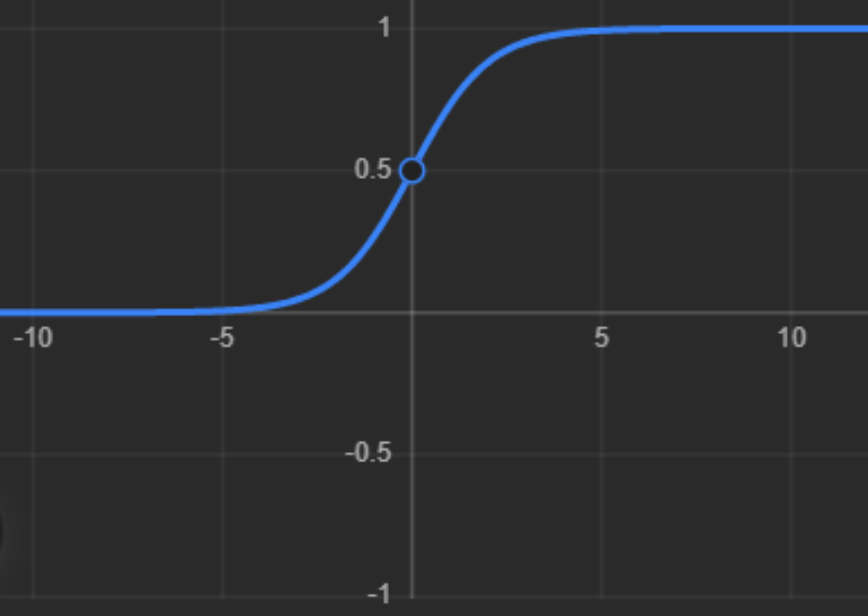
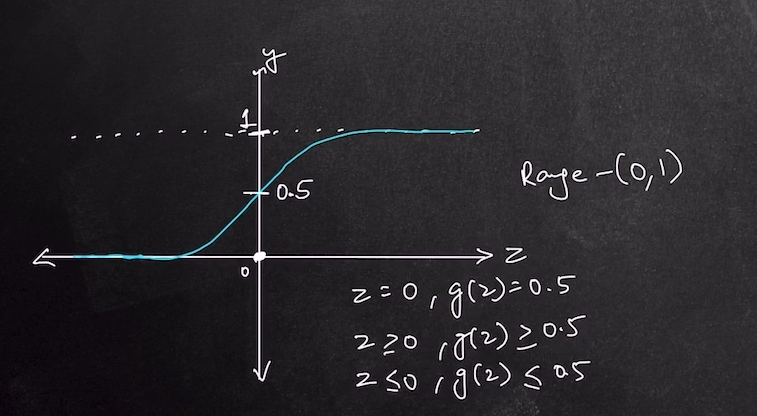


Notice

When

[
z=0
]

the output is

[
g(z)=0.5
]



---

## If z > 0

Example

[
z=4
]

Sigmoid

≈0.982

Very likely Class 1.

---

## If z < 0

Example

[
z=-4
]

Sigmoid

≈0.018

Very likely Class 0.

---

## If z = 0

Sigmoid

=0.5

The model is completely uncertain.

---

# Step 6: Combining everything

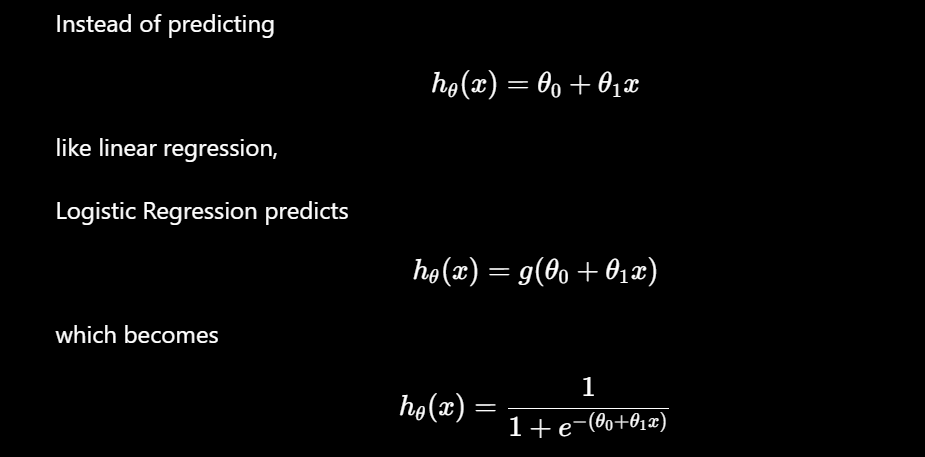

---

# Step 7: 

Instead of one feature,

suppose we have

Age

Income

Experience

Then

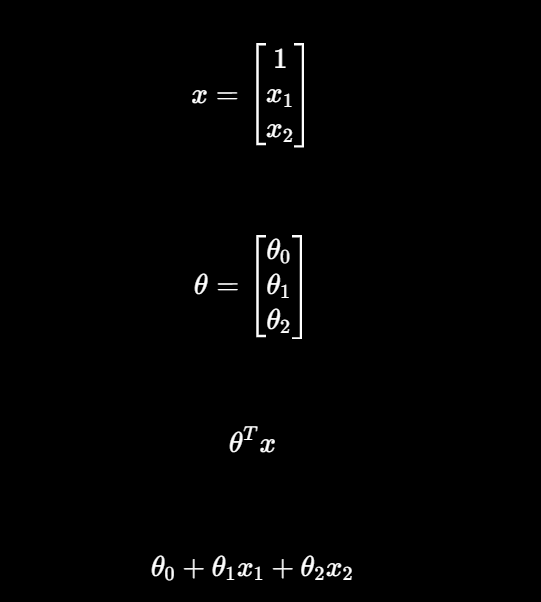

---

# Step 8: Final prediction

Suppose

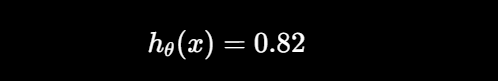

This means

**82% probability that the sample belongs to Class 1.**

Now we use a threshold.

Usually

```
Probability ≥ 0.5
        ↓
Class 1

Probability < 0.5
        ↓
Class 0
```

So

0.82 → Class 1

0.13 → Class 0

---

The key idea is that **Logistic Regression is still a linear model internally** because it first computes the linear score. The only difference from Linear Regression is that it **passes that score through the sigmoid function** to turn it into a probability that can be used for classification.


---
# Cost Function

### What is the purpose of a cost function?

Exactly the same as in Linear Regression.

It answers one question:

> **How bad are my predictions?**

If predictions are good,

Cost → small

If predictions are bad,

Cost → large

Then gradient descent tries to make this cost as small as possible.

---

# Why can't we use Mean Squared Error?

Because logistic regression predicts probabilities (0 to 1), not continuous values.

Using MSE gives a non-convex cost surface, causing gradient descent to get stuck in local minima.

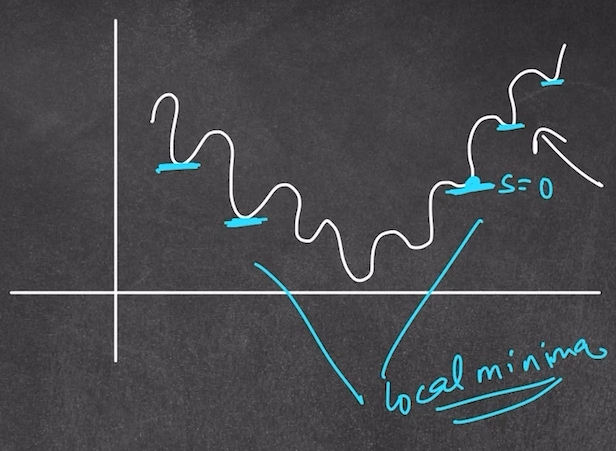

So we need another cost function.

That cost function is

**Log Loss (Binary Cross Entropy).**

---

# Think like a teacher grading an exam

Suppose

Actual answer

[
y=1
]


Now see different predictions.

| Predicted Probability | Good or Bad?   |
| --------------------- | -------------- |
| 0.99                  | Excellent      |
| 0.90                  | Good           |
| 0.70                  | Acceptable     |
| 0.51                  | Barely correct |
| 0.20                  | Very bad       |
| 0.01                  | Terrible       |

Should all wrong answers receive the same punishment?

No.

The more confident the model is **while being wrong**, the bigger the punishment should be.

That's exactly what log loss does.

---

# Case 1

Actual


y=1

Cost becomes

-log(y^)
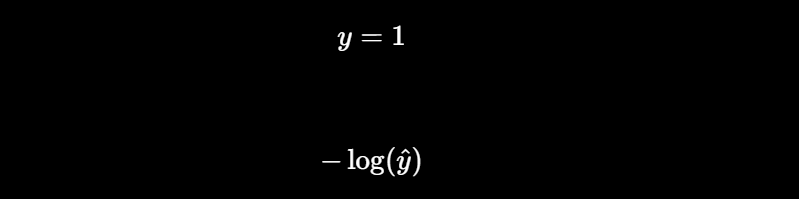


---

Suppose prediction

y hat= 1

Cost =0
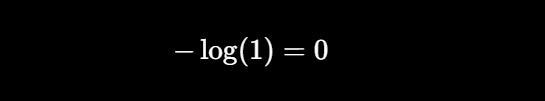


Perfect prediction.

No punishment.

---

Prediction


y hat =0.9

Cost

≈0.105
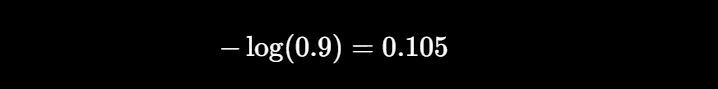
Tiny punishment.

---

Prediction

y hat = 0.5

Cost

≈0.693

Bigger punishment.

---

Prediction

y hat = 0.1

Cost

≈2.30

Very large punishment.

---

Prediction

y hat=0.001

Cost

≈6.9

Huge punishment.

Because the model was extremely confident and completely wrong.

That is why the graph shoots upward near 0.
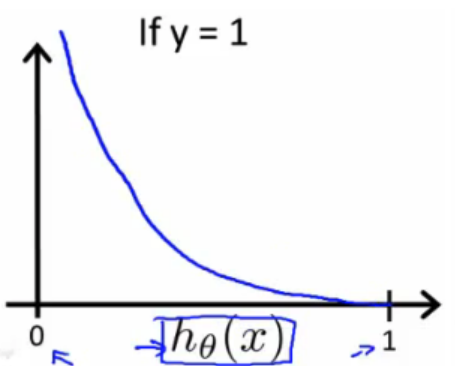

---

# Case 2

Suppose

Actual


y=0


Now we use
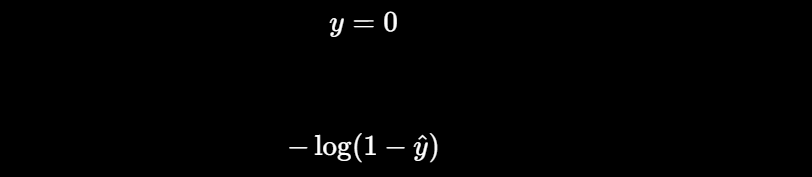


---

Prediction

0

Cost

0

Perfect.

---

Prediction

0.1

Very small cost.

---

Prediction

0.5

Medium cost.

---

Prediction

0.99

Huge cost.

Again,

Very confident

Very wrong

Very large punishment.

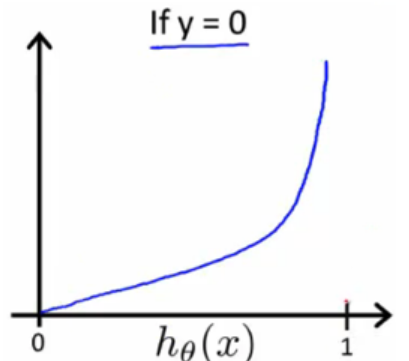
---

# Why two different formulas?

Because we have two classes.

When


y=1


we care about

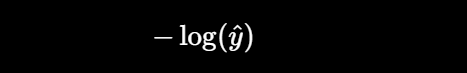

When


y=0


we care about

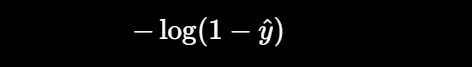

Instead of writing an if-else statement in mathematics, both are combined into one equation.

---

# The combined formula

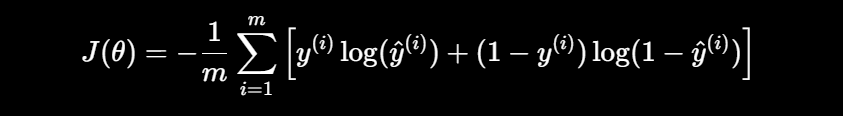

It looks scary, but it's just an if-else.

---

## If actual class is 1

Then


y=1


Substitute into the formula.

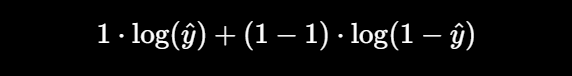

Second part disappears.

Only

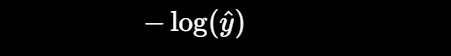

remains.

---

## If actual class is 0

Then


y=0


Substitute.

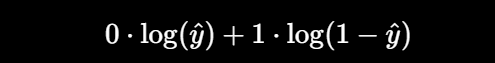

First part disappears.

Only

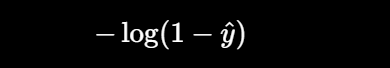

remains.

So the big equation automatically chooses the correct formula.

---

# What does the complete cost function do?

Suppose we have 5 training examples.

| Actual | Prediction | Individual Loss |
| ------ | ---------- | --------------- |
| 1      | 0.95       | 0.05            |
| 0      | 0.10       | 0.10            |
| 1      | 0.80       | 0.22            |
| 1      | 0.30       | 1.20            |
| 0      | 0.90       | 2.30            |

The total cost is simply

1. Compute the loss for each training example.
2. Add all the losses.
3. Divide by the number of examples (m).

That gives one number:

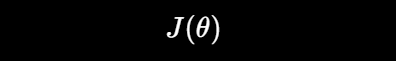

Gradient descent then changes the parameters thetas to reduce this average loss.

---

# Finally

The complete training process is

```
Training Data
      │
      ▼
Compute z = θᵀx
      │
      ▼
Apply Sigmoid
      │
      ▼
Predicted Probability (ŷ)
      │
      ▼
Compare with Actual Label (y)
      │
      ▼
Calculate Log Loss
      │
      ▼
Average all losses → J(θ)
      │
      ▼
Gradient Descent updates θ
      │
      ▼
Repeat until cost is minimum
```

### One sentence to remember

**Log loss measures how wrong the predicted probability is, and it punishes confident wrong predictions much more severely than uncertain ones.**
